[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/trim-filter-messages.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239435-lesson-4-trim-and-filter-messages)

# Filtering and trimming messages

## Review

Now, we have a deeper understanding of a few things: 

* How to customize the graph state schema
* How to define custom state reducers
* How to use multiple graph state schemas

## Goals

Now, we can start using these concepts with models in LangGraph!
 
In the next few sessions, we'll build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_ollama tiktoken

In [2]:
# Ollama - no API key required
# Make sure Ollama is installed and running: https://ollama.ai/
# Pull the llama3.1 model: ollama pull llama3.1:latest


⚠️ **Important**: This notebook uses the `llama3.1:latest` model, which supports advanced features. If you encounter issues, make sure you have pulled this specific model using `ollama pull llama3.1:latest`. Other models may not work correctly with the examples in this notebook.

We'll use [LangSmith](https://docs.langchain.com/langsmith/home) for [tracing](https://docs.langchain.com/langsmith/observability-concepts).

We'll log to a project, `langchain-academy`. 

In [3]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

# No API key needed for local Ollama
print("Using local Ollama - no API key required")

Using local Ollama - no API key required


In [4]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

## Messages as state

First, let's define some messages.

In [5]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


Recall we can pass them to a chat model.

In [6]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="llama3.1:latest")
llm.invoke(messages)

AIMessage(content='There are many fascinating ocean mammals beyond whales! Here are some other species you might find interesting:\n\n1. **Dolphins**: Like whales, dolphins belong to the toothed whale family (Delphinidae). They\'re highly intelligent and social animals known for their playful behavior.\n2. **Seals** and **Sea Lions**: These marine mammals belong to the pinniped family (Phocidae and Otariidae) and are characterized by their flippers and streamlined bodies.\n3. **Manatees** and **Dugongs**: Also known as sea cows, these large, slow-moving herbivores feed on seaweed and seagrass in shallow waters.\n4. **Walruses**: Another pinniped species, walruses are well-known for their distinctive tusks and ability to haul out of the water onto ice floes.\n5. **Monk Seals**: One of the most primitive seal species, monk seals are found in tropical and subtropical waters and are known for their unique appearance and behavior.\n\nYou might also want to explore some lesser-known ocean ma

We can run our chat model in a simple graph with `MessagesState`.

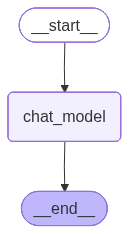

In [7]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There are many fascinating ocean mammals beyond whales! Here are some other ocean mammals you might find interesting:

1. **Dolphins**: Known for their intelligence and social behavior, dolphins are a popular topic of study and conservation efforts.
2. **Porpoises**: Similar to dolphins, but with a more robust body and smaller dorsal fin, porpoises are often overlooked but still play an important role in marine ecosystems.
3. **Manatees**: Also known as sea cows, manatees are large, slow-moving herbivores found in shallow waters of the Caribbean and Gulf of Mexico.
4. **Dugongs**: Related to manatees, dugongs are

## Reducer

A practical challenge when working with messages is managing long-running conversations. 

Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

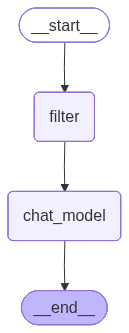

In [9]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There's a wonderful diversity of ocean mammals beyond whales! Here are some fascinating ones to explore:

1. **Dolphins**: These intelligent and social creatures are closely related to whales but have a more streamlined body shape.
2. **Porpoises**: Similar to dolphins, but with a more robust body and a smaller dorsal fin.
3. **Seals** (Pinnipeds): A group that includes harbor seals, elephant seals, and sea lions. They use flippers for propulsion and can often be found on land or ice.
4. **Manatees**: Large, slow-moving aquatic mammals that inhabit shallow waters in the Caribbean and Gulf of Mexico.
5. **Dugongs*

## Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

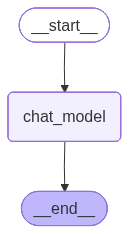

In [11]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take our existing list of messages, append the above LLM response, and append a follow-up question.

In [12]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

In [13]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There's a wonderful diversity of ocean mammals beyond whales! Here are some fascinating ones to explore:

1. **Dolphins**: These intelligent and social creatures are closely related to whales but have a more streamlined body shape.
2. **Porpoises**: Similar to dolphins, but with a more robust body and a smaller dorsal fin.
3. **Seals** (Pinnipeds): A group that includes harbor seals, elephant seals, and sea lions. They use

In [14]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There's a wonderful diversity of ocean mammals beyond whales! Here are some fascinating ones to explore:

1. **Dolphins**: These intelligent and social creatures are closely related to whales but have a more streamlined body shape.
2. **Porpoises**: Similar to dolphins, but with a more robust body and a smaller dorsal fin.
3. **Seals** (Pinnipeds): A group that includes harbor seals, elephant seals, and sea lions. They use

The state has all of the mesages.

But, let's look at the LangSmith trace to see that the model invocation only uses the last message:

https://smith.langchain.com/public/75aca3ce-ef19-4b92-94be-0178c7a660d9/r

## Trim messages

Another approach is to [trim messages](https://docs.langchain.com/oss/python/langgraph/add-memory#trim-messages), based upon a set number of tokens. 

This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the `trim_messages` below.

> **Note (Ollama):** The `trim_messages` function accepts a `token_counter` parameter. With OpenAI models, you can pass the model directly, but `ChatOllama` doesn't expose a native token counting method — LangChain falls back to downloading a GPT-2 tokenizer from HuggingFace, which is inaccurate and triggers authentication warnings. Instead, we use `tiktoken` locally to get an accurate token count without any HuggingFace dependency.

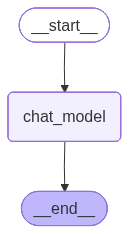

In [15]:
import tiktoken
from langchain_core.messages import trim_messages, BaseMessage

# Accurate token counter using tiktoken locally.
# This avoids the HuggingFace GPT-2 tokenizer fallback that ChatOllama triggers.
def llama3_tokenizer(messages: list[BaseMessage]) -> int:
    encoding = tiktoken.encoding_for_model("gpt-4o")
    total_tokens = 0
    for msg in messages:
        total_tokens += 4  # Overhead for message roles
        if isinstance(msg.content, str):
            total_tokens += len(encoding.encode(msg.content))
    return total_tokens

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=llama3_tokenizer,
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [17]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=llama3_tokenizer,
            allow_partial=False
        )

[HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Lance')]

In [18]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

Let's look at the LangSmith trace to see the model invocation:

https://smith.langchain.com/public/b153f7e9-f1a5-4d60-8074-f0d7ab5b42ef/r